# NB-06 | Final Comparison — Итоговое сравнение всех бейзлайнов (Окончательный вывод - в конце ноутбука)

Читает все runs из MLflow-эксперимента и сравнивает их по трём метрикам:  
- **KID mean** (↓ ниже = лучше — ближе к референсному стилю)  
- **CLIP Score** (↑ выше = лучше — точнее следует промпту)  
- **LPIPS Diversity** (чем выше, тем разнообразнее — нет mode collapse)

Строит bar chart, логирует CSV-таблицу в MLflow как summary artifact.

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

MLFLOW_URI      = 'http://127.0.0.1:5000'
EXPERIMENT_NAME = 'anima_baseline_benchmarks'

mlflow.set_tracking_uri(MLFLOW_URI)
print('MLflow connected ✓')

e:\Projects\Auto-VideoGame-Assets-Pipeline\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow connected ✓


## 1. Загружаем все runs из эксперимента

In [2]:
client = mlflow.tracking.MlflowClient()

exp = client.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise RuntimeError(f'Experiment "{EXPERIMENT_NAME}" not found. Run NB-01..05 first.')

runs = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=['attribute.start_time DESC'],
)

print(f'Found {len(runs)} runs in experiment "{EXPERIMENT_NAME}"')
for r in runs:
    print(f'  {r.info.run_name:55s}  status={r.info.status}')

Found 9 runs in experiment "anima_baseline_benchmarks"
  eval_baseline_5_propsLoRA_llmExpand                      status=FINISHED
  eval_baseline_4_charLoRA_llmExpand                       status=FINISHED
  eval_baseline_3_propsLoRA_cfg2.0_w0.85                   status=FINISHED
  eval_baseline_2_charLoRA_cfg2.0_w0.85                    status=FINISHED
  eval_baseline_1_turbo_only_cfg2.0_steps12                status=FINISHED
  eval_baseline_1_turbo_only_cfg2.0_steps12                status=FAILED
  eval_baseline_1_turbo_only_cfg2.0_steps12                status=FAILED
  eval_baseline_1_turbo_only_cfg2.0_steps12                status=FAILED
  eval_baseline_1_turbo_only_cfg2.0_steps12                status=FAILED


## 2. Строим сводную таблицу

In [3]:
rows = []
for r in runs:
    m = r.data.metrics
    t = r.data.tags
    p = r.data.params
    rows.append({
        'run_name':        r.info.run_name,
        'baseline_id':     p.get('infer.baseline_id', t.get('baseline_id', '?')),
        'family':          t.get('family', '?'),
        'lora_stack':      p.get('model.lora_stack', '?'),
        'llm_expansion':   p.get('infer.llm_expansion', '?'),
        'style_strength':  p.get('infer.style_strength', '?'),
        'kid_mean':        m.get('eval.kid_mean', None),
        'kid_std':         m.get('eval.kid_std', None),
        'clip_score':      m.get('eval.clip_score', None),
        'lpips_diversity': m.get('eval.lpips_diversity', None),
        'n_generated':     m.get('eval.n_generated', None),
        'run_id':          r.info.run_id,
        'warning':         t.get('warning', ''),
    })

df = pd.DataFrame(rows).sort_values('baseline_id')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df[['baseline_id','family','lora_stack','llm_expansion','kid_mean','clip_score','lpips_diversity']].to_string())

  baseline_id     family       lora_stack llm_expansion  kid_mean  clip_score  lpips_diversity
4  baseline_1  character       turbo_only         False  0.073195    0.304185         0.691435
5  baseline_1  character       turbo_only         False       NaN         NaN              NaN
6  baseline_1  character       turbo_only         False       NaN         NaN              NaN
7  baseline_1  character       turbo_only         False       NaN         NaN              NaN
8  baseline_1  character       turbo_only         False       NaN         NaN              NaN
3  baseline_2  character  turbo+character         False  0.042832    0.299316         0.691749
2  baseline_3      props      turbo+props         False  0.038077    0.319646         0.698303
1  baseline_4  character  turbo+character          True  0.056798    0.292212         0.651394
0  baseline_5      props      turbo+props          True  0.036467    0.271003         0.665948


## 3. Визуализация — bar chart по трём метрикам

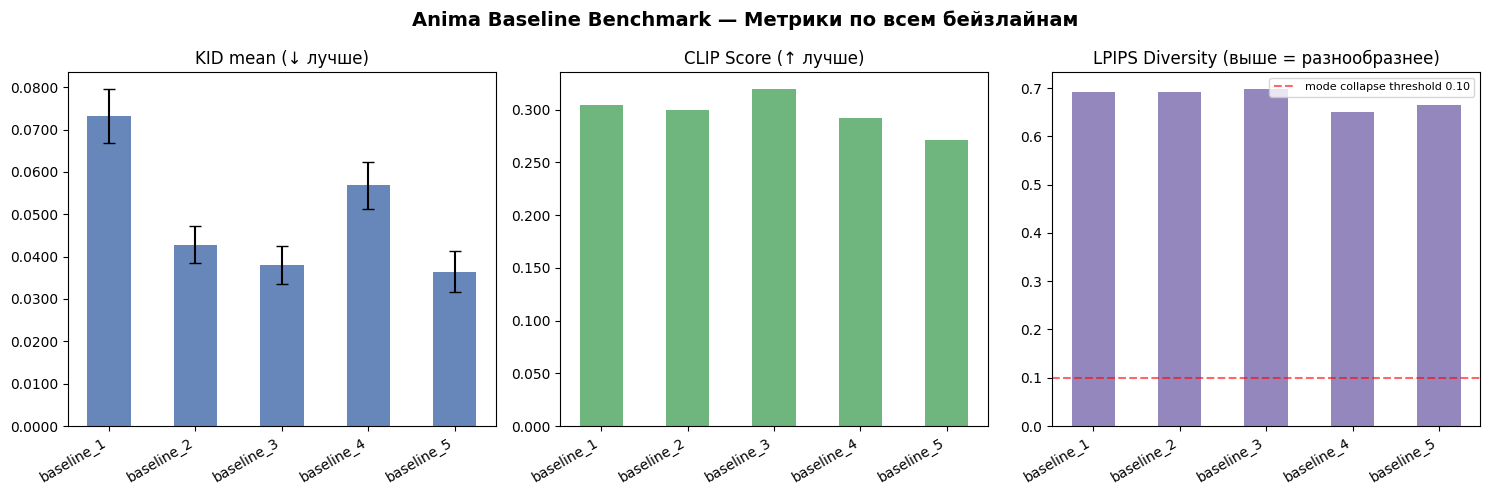

Chart saved ✓


In [4]:
df_plot = df.dropna(subset=['kid_mean','clip_score','lpips_diversity']).copy()
df_plot = df_plot.sort_values('baseline_id')

labels = df_plot['baseline_id'].tolist()
x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Anima Baseline Benchmark — Метрики по всем бейзлайнам', fontsize=14, fontweight='bold')

# KID mean (↓ better)
axes[0].bar(x, df_plot['kid_mean'], width=0.5, color='#4C72B0', alpha=0.85)
if 'kid_std' in df_plot.columns:
    axes[0].errorbar(x, df_plot['kid_mean'], yerr=df_plot['kid_std'], fmt='none', color='black', capsize=4)
axes[0].set_title('KID mean (↓ лучше)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# CLIP score (↑ better)
axes[1].bar(x, df_plot['clip_score'], width=0.5, color='#55A868', alpha=0.85)
axes[1].set_title('CLIP Score (↑ лучше)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# LPIPS diversity (higher = more diverse)
colors = ['#DD8452' if v < 0.10 else '#C44E52' if v < 0.08 else '#8172B3' for v in df_plot['lpips_diversity']]
axes[2].bar(x, df_plot['lpips_diversity'], width=0.5, color=colors, alpha=0.85)
axes[2].axhline(0.10, color='red', linestyle='--', alpha=0.6, label='mode collapse threshold 0.10')
axes[2].set_title('LPIPS Diversity (выше = разнообразнее)')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].legend(fontsize=8)

plt.tight_layout()
Path('tmp').mkdir(parents=True, exist_ok=True)
chart_path = 'tmp/benchmark_comparison_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

## 4. Автоматический вывод лучших run по каждой метрике

In [5]:
df_v = df.dropna(subset=['kid_mean','clip_score','lpips_diversity'])

best_kid   = df_v.loc[df_v['kid_mean'].idxmin()]
best_clip  = df_v.loc[df_v['clip_score'].idxmax()]
best_lpips = df_v.loc[df_v['lpips_diversity'].idxmax()]

print('=== Best runs ===')
print(f'Best KID    (↓): {best_kid["baseline_id"]:15s}  KID={best_kid["kid_mean"]:.6f}')
print(f'Best CLIP   (↑): {best_clip["baseline_id"]:15s}  CLIP={best_clip["clip_score"]:.4f}')
print(f'Best LPIPS  (↑): {best_lpips["baseline_id"]:15s}  LPIPS={best_lpips["lpips_diversity"]:.4f}')

# Предупреждения по mode collapse
mc_risk = df_v[df_v['lpips_diversity'] < 0.10]
if not mc_risk.empty:
    print(f'\n⚠ Mode collapse risk (LPIPS < 0.10):')
    for _, r in mc_risk.iterrows():
        print(f'  {r["baseline_id"]}: LPIPS={r["lpips_diversity"]:.4f}')

=== Best runs ===
Best KID    (↓): baseline_5       KID=0.036467
Best CLIP   (↑): baseline_3       CLIP=0.3196
Best LPIPS  (↑): baseline_3       LPIPS=0.6983


## 5. Логируем summary в MLflow как отдельный Summary Run

In [6]:
Path('tmp').mkdir(parents=True, exist_ok=True)
csv_path = 'tmp/benchmark_summary.csv'
df.to_csv(csv_path, index=False)

with mlflow.start_run(run_name='SUMMARY_all_baselines') as run:
    mlflow.set_tags({
        'evaluation_type': 'summary',
        'n_baselines': str(len(df)),
    })

    # Логируем лучшие значения
    if not df_v.empty:
        mlflow.log_metrics({
            'best.kid_mean':        float(df_v['kid_mean'].min()),
            'best.clip_score':      float(df_v['clip_score'].max()),
            'best.lpips_diversity': float(df_v['lpips_diversity'].max()),
        })

    mlflow.log_artifact(csv_path, artifact_path='reports')
    mlflow.log_artifact(chart_path, artifact_path='reports')

    print(f'Summary run logged: {run.info.run_id}')
    print(f'Open MLflow UI: {MLFLOW_URI}')

Summary run logged: bfa270762d534045b74f16fd1904ba3b
Open MLflow UI: http://127.0.0.1:5000
🏃 View run SUMMARY_all_baselines at: http://127.0.0.1:5000/#/experiments/0/runs/bfa270762d534045b74f16fd1904ba3b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0
